# Notebook 11 — SEI-only Entry Audit

## Goal

This notebook audits the entry point for an SEI-only aging branch in the PyBaMM Aging Bridge project.

The goal is not to run a long aging study yet. Instead, this notebook checks whether a controlled SEI-only model configuration can be instantiated, solved, and inspected for aging-related output variables.

## Scientific context

Previous notebooks established a mechanism-to-observable fingerprint framework based on controlled DFN-level perturbations:

- `Ds_p` reduction → diffusion-sensitive tau fingerprint
- `j0_n` reduction → negative-electrode kinetic / Ri fingerprint
- `j0_p` reduction → positive-electrode kinetic / Ri fingerprint
- `contact_R` increase → pure ohmic/contact fingerprint

The next step is to introduce a real degradation submodel and ask:

Does SEI growth produce an observable fingerprint that resembles one of the previously isolated perturbation families, or does it create a mixed diagnostic signature?

## Why SEI first?

SEI growth is selected before lithium plating because it is a more stable and standard entry point for lithium-ion battery aging modeling.

It is expected to affect:

- loss of lithium inventory,
- capacity fade,
- film resistance or interfacial resistance,
- possibly HPPC-derived Ri,
- possibly voltage relaxation behavior.

Lithium plating will be treated later as a separate low-temperature / fast-charge stress branch.

## Workflow

1. Import packages and audit project paths.
2. Inspect available PyBaMM parameter sets relevant to SEI aging.
3. Instantiate candidate SEI-only DFN configurations.
4. Inspect available SEI / LLI / capacity / degradation variables.
5. Run a short SEI-enabled cycling smoke test.
6. Export a small audit table of accessible aging variables.
7. Decide whether the next notebook can proceed to SEI-only cycling + RPT fingerprint extraction.

## Expected outputs

- SEI option audit table
- degradation-variable inventory
- short SEI-enabled cycling smoke-test result
- decision on which SEI configuration to use next

## Interpretation boundary

This notebook does not establish an aging law, SOH trajectory, or validated SEI degradation model.

A successful result only means:

- the SEI model configuration is runnable,
- SEI-related variables are accessible,
- a future SEI-only cycling + RPT notebook can be designed.

No conclusion about real-cell SEI behavior is made in this notebook.

In [1]:
# Cell 1 — Imports and path audit（导入库并确认项目路径）

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

print("PyBaMM version:", pybamm.__version__)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"
FIGURES = ROOT / "figures"

DATA.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("DATA:", DATA)
print("FIGURES:", FIGURES)

PyBaMM version: 26.3.1
ROOT: /Users/louislu/projects/pybamm-aging-bridge
DATA: /Users/louislu/projects/pybamm-aging-bridge/data
FIGURES: /Users/louislu/projects/pybamm-aging-bridge/figures


In [2]:
# Cell 2 — Parameter-set availability audit（检查可用参数集）

candidate_parameter_sets = [
    "Chen2020",
    "OKane2022",
    "ORegan2022",
]

availability_rows = []

for name in candidate_parameter_sets:
    try:
        p = pybamm.ParameterValues(name)
        availability_rows.append(
            {
                "parameter_set": name,
                "available": True,
                "n_parameters": len(list(p.keys())),
                "error": "",
            }
        )
    except Exception as e:
        availability_rows.append(
            {
                "parameter_set": name,
                "available": False,
                "n_parameters": np.nan,
                "error": repr(e),
            }
        )

parameter_set_audit = pd.DataFrame(availability_rows)
display(parameter_set_audit)

,parameter_set,available,n_parameters,error
0,Chen2020,True,93,
1,OKane2022,True,131,
2,ORegan2022,True,76,


In [3]:
# Cell 3 — SEI option instantiation audit（审计哪些 SEI-only 配置能成功实例化）

sei_option_candidates = [
    "constant",
    "reaction limited",
    "solvent-diffusion limited",
    "electron-migration limited",
    "interstitial-diffusion limited",
    "ec reaction limited",
]

sei_audit_rows = []

for sei_option in sei_option_candidates:
    options = {
        "SEI": sei_option,
        "lithium plating": "none",
        "loss of active material": "none",
        "particle mechanics": "none",
        "SEI porosity change": "false",
    }

    try:
        model = pybamm.lithium_ion.DFN(options)
        variable_matches = [
            k for k in model.variables.keys()
            if ("sei" in k.lower())
            or ("lithium inventory" in k.lower())
            or ("capacity" in k.lower())
            or ("loss of lithium" in k.lower())
        ]

        sei_audit_rows.append(
            {
                "SEI_option": sei_option,
                "instantiates": True,
                "n_matching_variables": len(variable_matches),
                "example_variables": variable_matches[:8],
                "error": "",
            }
        )

    except Exception as e:
        sei_audit_rows.append(
            {
                "SEI_option": sei_option,
                "instantiates": False,
                "n_matching_variables": np.nan,
                "example_variables": [],
                "error": repr(e),
            }
        )

sei_option_audit = pd.DataFrame(sei_audit_rows)
display(sei_option_audit)

out_csv = DATA / "sei_option_instantiation_audit.csv"
sei_option_audit.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)

,SEI_option,instantiates,n_matching_variables,example_variables,error
0,constant,True,68,"[Discharge capacity [A.h], Throughput capacity...",
1,reaction limited,True,68,"[Discharge capacity [A.h], Throughput capacity...",
2,solvent-diffusion limited,True,68,"[Discharge capacity [A.h], Throughput capacity...",
3,electron-migration limited,True,68,"[Discharge capacity [A.h], Throughput capacity...",
4,interstitial-diffusion limited,True,68,"[Discharge capacity [A.h], Throughput capacity...",
5,ec reaction limited,True,68,"[Discharge capacity [A.h], Throughput capacity...",


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_option_instantiation_audit.csv


In [4]:
# Cell 4 — Select provisional SEI-only configuration（选择临时 SEI-only 配置）

SEI_OPTION = "solvent-diffusion limited"
PARAMETER_SET = "OKane2022"

SEI_ONLY_OPTIONS = {
    "SEI": SEI_OPTION,
    "lithium plating": "none",
    "loss of active material": "none",
    "particle mechanics": "none",
    "SEI porosity change": "false",
}

print("Selected parameter set:", PARAMETER_SET)
print("Selected SEI option:", SEI_OPTION)
print("Model options:", SEI_ONLY_OPTIONS)

model = pybamm.lithium_ion.DFN(SEI_ONLY_OPTIONS)
param = pybamm.ParameterValues(PARAMETER_SET)

print("[OK] provisional SEI-only model and parameter set loaded")

Selected parameter set: OKane2022
Selected SEI option: solvent-diffusion limited
Model options: {'SEI': 'solvent-diffusion limited', 'lithium plating': 'none', 'loss of active material': 'none', 'particle mechanics': 'none', 'SEI porosity change': 'false'}
[OK] provisional SEI-only model and parameter set loaded


In [5]:
# Cell 5 — SEI / LLI / capacity variable inventory（SEI/LLI/容量变量库存审计）

variable_keywords = [
    "sei",
    "lithium inventory",
    "loss of lithium",
    "lithium lost",
    "capacity",
    "lli",
]

inventory_rows = []

for var_name in model.variables.keys():
    lower = var_name.lower()
    matched_keywords = [kw for kw in variable_keywords if kw in lower]

    if matched_keywords:
        inventory_rows.append(
            {
                "variable": var_name,
                "matched_keywords": ", ".join(matched_keywords),
            }
        )

sei_variable_inventory = pd.DataFrame(inventory_rows)

display(sei_variable_inventory)

out_csv = DATA / "sei_variable_inventory.csv"
sei_variable_inventory.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
print("Number of matched variables:", len(sei_variable_inventory))

,variable,matched_keywords
0,Discharge capacity [A.h],capacity
1,Throughput capacity [A.h],capacity
2,Negative electrode capacity [A.h],capacity
3,Loss of lithium due to loss of active material...,loss of lithium
4,Positive electrode capacity [A.h],capacity
...,...,...
68,Total lithium lost [mol],lithium lost
69,Total lithium lost from particles [mol],lithium lost
70,Total lithium lost from electrolyte [mol],lithium lost
71,Total lithium lost to side reactions [mol],lithium lost


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_variable_inventory.csv
Number of matched variables: 73


In [6]:
# Cell 6 — SEI-only one-cycle smoke test（SEI-only 单循环冒烟测试）

experiment = pybamm.Experiment(
    [
        "Discharge at C/3 until 2.5 V",
        "Rest for 10 minutes",
        "Charge at C/3 until 4.2 V",
        "Hold at 4.2 V until C/100",
        "Rest for 10 minutes",
    ],
    period="60 seconds",
)

sim = pybamm.Simulation(
    model,
    parameter_values=param,
    experiment=experiment,
)

# Start near full cell state for discharge-first smoke test.
sim.set_initial_soc(1.0, direction="discharge")

solution = sim.solve()

print("[OK] SEI-only one-cycle smoke test solved")
print("Termination:", solution.termination)
print("Final time [h]:", float(solution["Time [h]"].entries[-1]))

[OK] SEI-only one-cycle smoke test solved
Termination: final time
Final time [h]: 7.124432131509622


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_only_one_cycle_smoke_trace.csv


,time_s,time_h,voltage_V,current_A_pybamm,discharge_capacity_Ah,throughput_capacity_Ah,current_A_exp
0,0.0,0.000000,4.130157,1.666667,0.000000,0.000000,-1.666667
1,60.0,0.016667,4.083782,1.666667,0.027778,0.027778,-1.666667
2,120.0,0.033333,4.066202,1.666667,0.055556,0.055556,-1.666667
3,180.0,0.050000,4.054951,1.666667,0.083333,0.083333,-1.666667
4,240.0,0.066667,4.046906,1.666667,0.111111,0.111111,-1.666667


,time_s,time_h,voltage_V,current_A_pybamm,discharge_capacity_Ah,throughput_capacity_Ah,current_A_exp
428,25407.955673,7.057765,4.194938,0.0,0.011627,10.087404,-0.0
429,25467.955673,7.074432,4.194832,0.0,0.011627,10.087404,-0.0
430,25527.955673,7.091099,4.194745,0.0,0.011627,10.087404,-0.0
431,25587.955673,7.107765,4.194674,0.0,0.011627,10.087404,-0.0
432,25647.955673,7.124432,4.194617,0.0,0.011627,10.087404,-0.0


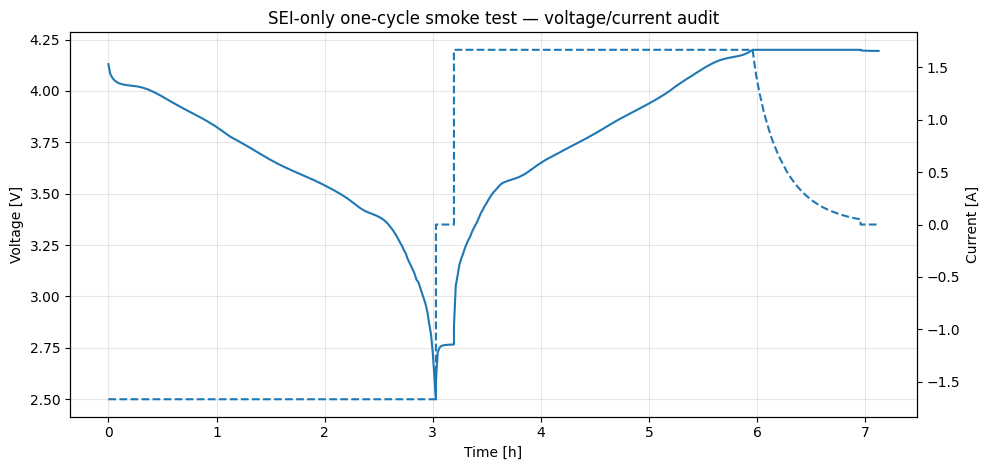

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_only_one_cycle_voltage_current_audit.png


In [7]:
# Cell 7 — Basic voltage/current/capacity plot（基础电压/电流/容量曲线审计）

df_smoke = pd.DataFrame(
    {
        "time_s": solution["Time [s]"].entries,
        "time_h": solution["Time [h]"].entries,
        "voltage_V": solution["Terminal voltage [V]"].entries,
        "current_A_pybamm": solution["Current [A]"].entries,
        "discharge_capacity_Ah": solution["Discharge capacity [A.h]"].entries,
        "throughput_capacity_Ah": solution["Throughput capacity [A.h]"].entries,
    }
)

df_smoke["current_A_exp"] = -df_smoke["current_A_pybamm"]
# PyBaMM convention: +I = discharge, -I = charge
# Experimental convention used for plotting: +I_exp = charge, -I_exp = discharge

out_csv = DATA / "sei_only_one_cycle_smoke_trace.csv"
df_smoke.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(df_smoke.head())
display(df_smoke.tail())

fig, ax1 = plt.subplots(figsize=(10, 4.8))

ax1.plot(df_smoke["time_h"], df_smoke["voltage_V"], label="Voltage [V]")
ax1.set_xlabel("Time [h]")
ax1.set_ylabel("Voltage [V]")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    df_smoke["time_h"],
    df_smoke["current_A_exp"],
    linestyle="--",
    label="Current [A], exp convention",
)
ax2.set_ylabel("Current [A]")

plt.title("SEI-only one-cycle smoke test — voltage/current audit")

fig.tight_layout()
fig_path = FIGURES / "sei_only_one_cycle_voltage_current_audit.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

In [8]:
# Cell 8 — Candidate degradation variables（筛选可用于 SEI-only 审计的候选老化变量）

candidate_keywords = [
    "SEI thickness",
    "SEI resistance",
    "Loss of lithium inventory",
    "lithium lost",
    "capacity lost",
    "side reactions",
    "SEI interfacial current",
    "SEI concentration",
]

candidate_rows = []

for var_name in model.variables.keys():
    lower = var_name.lower()
    matched = [kw for kw in candidate_keywords if kw.lower() in lower]

    if matched:
        candidate_rows.append(
            {
                "variable": var_name,
                "matched_keywords": ", ".join(matched),
            }
        )

candidate_degradation_variables = pd.DataFrame(candidate_rows)

display(candidate_degradation_variables)

out_csv = DATA / "sei_candidate_degradation_variables.csv"
candidate_degradation_variables.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
print("Number of candidate variables:", len(candidate_degradation_variables))

,variable,matched_keywords
0,Negative SEI concentration [mol.m-3],SEI concentration
1,X-averaged negative SEI concentration [mol.m-3],SEI concentration
2,Volume-averaged negative SEI concentration [mo...,SEI concentration
3,Positive SEI concentration [mol.m-3],SEI concentration
4,X-averaged positive SEI concentration [mol.m-3],SEI concentration
5,Volume-averaged positive SEI concentration [mo...,SEI concentration
6,Positive electrode SEI interfacial current den...,SEI interfacial current
7,X-averaged positive electrode SEI interfacial ...,SEI interfacial current
8,Negative SEI thickness [m],SEI thickness
9,X-averaged negative SEI thickness [m],SEI thickness


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_candidate_degradation_variables.csv
Number of candidate variables: 23


In [9]:
# Cell 9 — Extract key SEI / LLI variables（提取关键 SEI / LLI 动态变量）

def first_available_variable(solution, candidates):
    """
    Return the first available variable name from candidate list.
    """
    available = []
    for name in candidates:
        try:
            _ = solution[name].entries
            available.append(name)
        except KeyError:
            pass

    return available[0] if available else None


key_variable_candidates = {
    "sei_thickness_m": [
        "X-averaged negative SEI thickness [m]",
        "X-averaged SEI thickness [m]",
        "Negative SEI thickness [m]",
    ],
    "loss_lithium_inventory_pct": [
        "Loss of lithium inventory [%]",
    ],
    "total_lithium_lost_mol": [
        "Total lithium lost [mol]",
        "Total lithium lost to side reactions [mol]",
    ],
    "capacity_lost_side_reactions_Ah": [
        "Total capacity lost to side reactions [A.h]",
        "Loss of capacity to negative SEI [A.h]",
        "Loss of capacity to SEI [A.h]",
    ],
    "sei_interfacial_current_A_m2": [
        "X-averaged negative electrode SEI interfacial current density [A.m-2]",
        "X-averaged SEI interfacial current density [A.m-2]",
    ],
}

selected_variables = {}

for short_name, candidates in key_variable_candidates.items():
    selected = first_available_variable(solution, candidates)
    selected_variables[short_name] = selected

selected_variables

{'sei_thickness_m': 'X-averaged negative SEI thickness [m]',
 'loss_lithium_inventory_pct': 'Loss of lithium inventory [%]',
 'total_lithium_lost_mol': 'Total lithium lost [mol]',
 'capacity_lost_side_reactions_Ah': 'Total capacity lost to side reactions [A.h]',
 'sei_interfacial_current_A_m2': 'X-averaged negative electrode SEI interfacial current density [A.m-2]'}

In [10]:
# Cell 10 — Build SEI dynamic audit dataframe（构建 SEI 动态变量随时间变化表）

sei_dynamic = pd.DataFrame(
    {
        "time_s": solution["Time [s]"].entries,
        "time_h": solution["Time [h]"].entries,
        "voltage_V": solution["Terminal voltage [V]"].entries,
        "current_A_pybamm": solution["Current [A]"].entries,
    }
)

sei_dynamic["current_A_exp"] = -sei_dynamic["current_A_pybamm"]

for short_name, var_name in selected_variables.items():
    if var_name is None:
        print(f"[WARN] No available variable found for {short_name}")
        continue

    values = solution[var_name].entries
    values = np.asarray(values)

    # If the variable is spatially resolved, reduce it to a mean trace for audit.
    if values.ndim == 1:
        trace = values
    else:
        trace = np.mean(values, axis=0)

    sei_dynamic[short_name] = trace
    print(f"[OK] extracted {short_name} from: {var_name}")

out_csv = DATA / "sei_only_one_cycle_degradation_trace.csv"
sei_dynamic.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(sei_dynamic.head())
display(sei_dynamic.tail())

[OK] extracted sei_thickness_m from: X-averaged negative SEI thickness [m]
[OK] extracted loss_lithium_inventory_pct from: Loss of lithium inventory [%]
[OK] extracted total_lithium_lost_mol from: Total lithium lost [mol]
[OK] extracted capacity_lost_side_reactions_Ah from: Total capacity lost to side reactions [A.h]
[OK] extracted sei_interfacial_current_A_m2 from: X-averaged negative electrode SEI interfacial current density [A.m-2]
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_only_one_cycle_degradation_trace.csv


,time_s,time_h,voltage_V,current_A_pybamm,current_A_exp,sei_thickness_m,loss_lithium_inventory_pct,total_lithium_lost_mol,capacity_lost_side_reactions_Ah,sei_interfacial_current_A_m2
0,0.0,0.000000,4.130157,1.666667,-1.666667,5.000000e-09,1.421085e-13,-5.551115e-17,0.000000e+00,-0.000013
1,60.0,0.016667,4.083782,1.666667,-1.666667,5.000758e-09,9.355396e-06,2.656615e-08,7.120123e-07,-0.000013
2,120.0,0.033333,4.066202,1.666667,-1.666667,5.001516e-09,1.870937e-05,5.312828e-08,1.423917e-06,-0.000013
3,180.0,0.050000,4.054951,1.666667,-1.666667,5.002273e-09,2.806194e-05,7.968639e-08,2.135713e-06,-0.000013
4,240.0,0.066667,4.046906,1.666667,-1.666667,5.003031e-09,3.741308e-05,1.062405e-07,2.847402e-06,-0.000013


,time_s,time_h,voltage_V,current_A_pybamm,current_A_exp,sei_thickness_m,loss_lithium_inventory_pct,total_lithium_lost_mol,capacity_lost_side_reactions_Ah,sei_interfacial_current_A_m2
428,25407.955673,7.057765,4.194938,0.0,-0.0,5.311289e-09,0.003842,0.000011,0.000292,-0.000012
429,25467.955673,7.074432,4.194832,0.0,-0.0,5.312003e-09,0.003851,0.000011,0.000293,-0.000012
430,25527.955673,7.091099,4.194745,0.0,-0.0,5.312716e-09,0.003860,0.000011,0.000294,-0.000012
431,25587.955673,7.107765,4.194674,0.0,-0.0,5.313430e-09,0.003869,0.000011,0.000294,-0.000012
432,25647.955673,7.124432,4.194617,0.0,-0.0,5.314143e-09,0.003878,0.000011,0.000295,-0.000012


In [11]:
# Cell 11 — SEI degradation variable delta summary（总结单循环前后老化变量变化）

delta_rows = []

for col in sei_dynamic.columns:
    if col in ["time_s", "time_h", "voltage_V", "current_A_pybamm", "current_A_exp"]:
        continue

    start_val = float(sei_dynamic[col].iloc[0])
    end_val = float(sei_dynamic[col].iloc[-1])
    delta = end_val - start_val

    if abs(start_val) > 1e-30:
        rel_pct = 100 * delta / start_val
    else:
        rel_pct = np.nan

    delta_rows.append(
        {
            "observable": col,
            "start_value": start_val,
            "end_value": end_val,
            "delta": delta,
            "relative_change_pct": rel_pct,
        }
    )

sei_delta_summary = pd.DataFrame(delta_rows)

out_csv = DATA / "sei_only_one_cycle_degradation_delta_summary.csv"
sei_delta_summary.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(sei_delta_summary)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_only_one_cycle_degradation_delta_summary.csv


,observable,start_value,end_value,delta,relative_change_pct
0,sei_thickness_m,5.000000e-09,5.314143e-09,3.141428e-10,6.282856e+00
1,loss_lithium_inventory_pct,1.421085e-13,3.877604e-03,3.877604e-03,2.728621e+12
2,total_lithium_lost_mol,-5.551115e-17,1.101108e-05,1.101108e-05,-1.983580e+13
3,capacity_lost_side_reactions_Ah,0.000000e+00,2.951133e-04,2.951133e-04,NaN
4,sei_interfacial_current_A_m2,-1.271677e-05,-1.196502e-05,7.517451e-07,-5.911448e+00


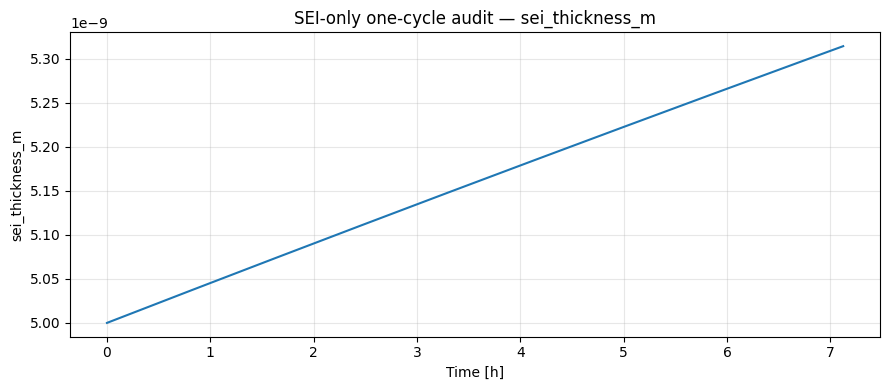

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_only_one_cycle_sei_thickness_m.png


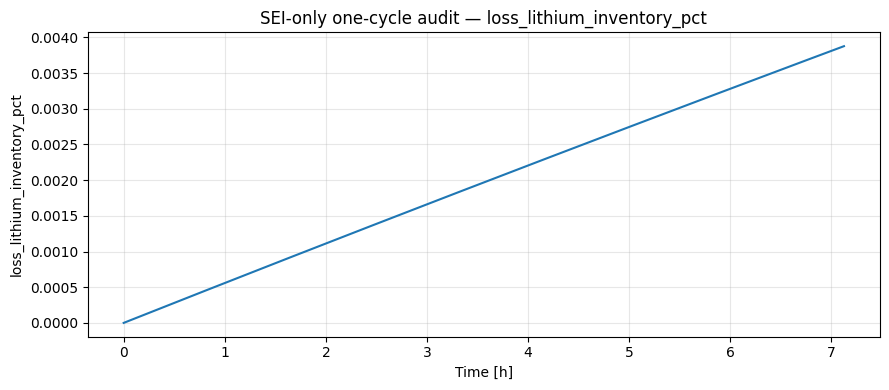

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_only_one_cycle_loss_lithium_inventory_pct.png


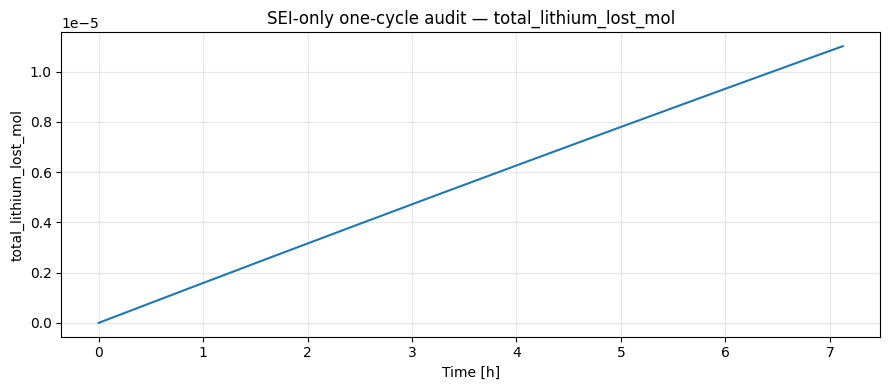

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_only_one_cycle_total_lithium_lost_mol.png


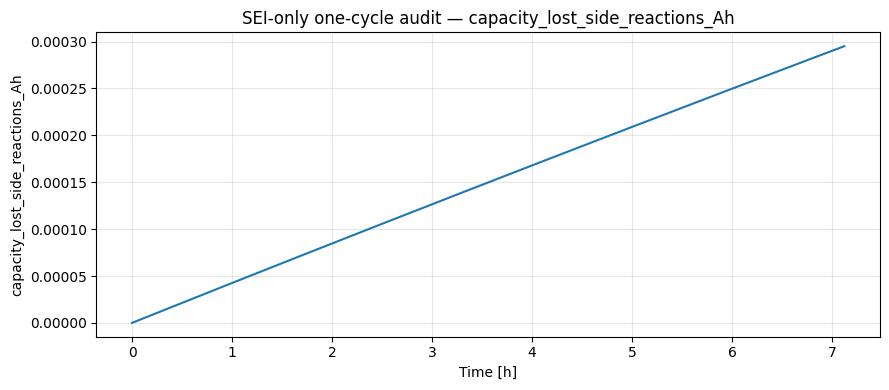

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/sei_only_one_cycle_capacity_lost_side_reactions_Ah.png


In [12]:
# Cell 12 — Plot SEI / LLI dynamic variables（绘制 SEI / LLI 变量随时间变化）

plot_cols = [
    col for col in [
        "sei_thickness_m",
        "loss_lithium_inventory_pct",
        "total_lithium_lost_mol",
        "capacity_lost_side_reactions_Ah",
    ]
    if col in sei_dynamic.columns
]

for col in plot_cols:
    fig, ax = plt.subplots(figsize=(9, 4))

    ax.plot(sei_dynamic["time_h"], sei_dynamic[col])
    ax.set_xlabel("Time [h]")
    ax.set_ylabel(col)
    ax.set_title(f"SEI-only one-cycle audit — {col}")
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    fig_path = FIGURES / f"sei_only_one_cycle_{col}.png"
    plt.savefig(fig_path, dpi=200)
    plt.show()

    print("[OK] saved:", fig_path)

In [13]:
# Cell 13 — SEI entry audit decision table（SEI-only 分支入口审计决策表）

sei_entry_decision_rows = [
    {
        "audit_item": "Parameter set availability",
        "result": "OKane2022 available",
        "status": "pass",
        "implication": "Aging-capable parameter set can be used for SEI branch.",
    },
    {
        "audit_item": "SEI option instantiation",
        "result": f"{SEI_OPTION} instantiated successfully",
        "status": "pass",
        "implication": "Selected SEI model option can be used in DFN.",
    },
    {
        "audit_item": "One-cycle solve",
        "result": "C/3 discharge-rest-charge-CV-rest solved to final time",
        "status": "pass",
        "implication": "SEI-only configuration is numerically runnable.",
    },
    {
        "audit_item": "SEI thickness",
        "result": f"Δ = {sei_delta_summary.loc[sei_delta_summary['observable']=='sei_thickness_m', 'delta'].iloc[0]:.3e} m",
        "status": "pass",
        "implication": "SEI growth is active and observable.",
    },
    {
        "audit_item": "Loss of lithium inventory",
        "result": f"end = {sei_dynamic['loss_lithium_inventory_pct'].iloc[-1]:.6f} %",
        "status": "pass",
        "implication": "LLI variable is accessible and increases during the cycle.",
    },
    {
        "audit_item": "Capacity lost to side reactions",
        "result": f"end = {sei_dynamic['capacity_lost_side_reactions_Ah'].iloc[-1]:.6e} Ah",
        "status": "pass",
        "implication": "Side-reaction capacity loss can be tracked.",
    },
    {
        "audit_item": "Next-stage readiness",
        "result": "Ready for SEI-only cycling + RPT design",
        "status": "pass",
        "implication": "Next notebook can insert RPT/HPPC checkpoints and map SEI aging to Ri/tau/capacity fingerprints.",
    },
]

sei_entry_decision_table = pd.DataFrame(sei_entry_decision_rows)

out_csv = DATA / "sei_only_entry_audit_decision_table.csv"
sei_entry_decision_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(sei_entry_decision_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/sei_only_entry_audit_decision_table.csv


,audit_item,result,status,implication
0,Parameter set availability,OKane2022 available,pass,Aging-capable parameter set can be used for SE...
1,SEI option instantiation,solvent-diffusion limited instantiated success...,pass,Selected SEI model option can be used in DFN.
2,One-cycle solve,C/3 discharge-rest-charge-CV-rest solved to fi...,pass,SEI-only configuration is numerically runnable.
3,SEI thickness,Δ = 3.141e-10 m,pass,SEI growth is active and observable.
4,Loss of lithium inventory,end = 0.003878 %,pass,LLI variable is accessible and increases durin...
5,Capacity lost to side reactions,end = 2.951133e-04 Ah,pass,Side-reaction capacity loss can be tracked.
6,Next-stage readiness,Ready for SEI-only cycling + RPT design,pass,Next notebook can insert RPT/HPPC checkpoints ...


# Notebook 11 Conclusion

This notebook audited the entry point for an SEI-only aging branch.

## Key findings

### 1. Parameter-set availability

The following parameter sets were available:

- `Chen2020`
- `OKane2022`
- `ORegan2022`

For the SEI-only branch, `OKane2022` was selected as the provisional parameter set because it is suitable for degradation-enabled simulations.

### 2. SEI model option availability

Several SEI options could be instantiated successfully, including:

- `constant`
- `reaction limited`
- `solvent-diffusion limited`
- `electron-migration limited`
- `interstitial-diffusion limited`
- `ec reaction limited`

The provisional SEI-only configuration used:

- `SEI = solvent-diffusion limited`
- `lithium plating = none`
- `loss of active material = none`
- `particle mechanics = none`
- `SEI porosity change = false`

### 3. One-cycle SEI smoke test

A C/3 discharge-rest-charge-CV-rest cycle was successfully solved.

The voltage/current profile was physically reasonable:

- C/3 discharge to 2.5 V,
- rest recovery,
- C/3 charge to 4.2 V,
- CV hold until C/100,
- final rest.

This confirms that the provisional SEI-only configuration is numerically runnable.

### 4. SEI and degradation variables are accessible

The model exposes SEI and degradation-related variables, including:

- SEI thickness,
- loss of lithium inventory,
- total lithium lost,
- capacity lost to side reactions,
- SEI interfacial current density.

These variables can be extracted as time series and used for later aging-fingerprint analysis.

### 5. SEI variables show active one-cycle evolution

During the one-cycle smoke test:

- SEI thickness increased,
- loss of lithium inventory increased,
- total lithium lost increased,
- capacity lost to side reactions increased.

This confirms that SEI growth is active, not merely enabled as a passive model option.

## Interpretation boundary

This notebook does not establish a physical aging law, SOH trajectory, or validated SEI degradation rate.

The observed one-cycle SEI changes are used only as an entry audit.

The correct conclusion is:

The selected SEI-only configuration is runnable, exposes relevant degradation variables, and is ready for a controlled SEI-only cycling + RPT fingerprint study.

## Next step

The next notebook should be:

`12_sei_only_cycling_rpt_fingerprint.ipynb`

Its purpose should be to run short SEI-only cycling with periodic RPT/HPPC checkpoints and extract:

- capacity loss,
- Ri drift,
- tau1/tau2 drift,
- SEI thickness growth,
- LLI growth,
- side-reaction capacity loss.

The key question will be:

Does SEI-only aging project mainly into an Ri-sensitive fingerprint, a capacity/LLI fingerprint, or a mixed observable signature?